In [6]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Importaciones de Scikit-Learn
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine 

# Estilo visual consistente con el proyecto NASA
sns.set_theme(style="whitegrid", palette="magma")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")

✅ Librerías importadas correctamente
   pandas   2.3.3
   numpy    2.4.3
   seaborn  0.13.2


In [7]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────────────────────
# CORRECCIONES aplicadas con el esquema real de 'neows_registros':
#   · Variables físicas: magnitud_absoluta, diametro_min_km, diametro_max_km
#   · Variable objetivo: 'es_peligroso' (booleano en Supabase) -> target 1/0
#   · Se filtran nulos en las métricas clave para asegurar la calidad del modelo

SQL_QUERY = """
SELECT
    id,
    nombre,
    magnitud_absoluta,
    diametro_min_km,
    diametro_max_km,
    CASE
        WHEN es_peligroso = TRUE THEN 1
        ELSE 0
    END AS target
FROM neows_registros
WHERE diametro_max_km IS NOT NULL 
  AND diametro_min_km IS NOT NULL
  AND magnitud_absoluta IS NOT NULL;
"""

with engine.connect() as conn:
    df_nasa = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df_nasa.shape[0]:,} filas × {df_nasa.shape[1]} columnas")
print(f"\nColumnas disponibles en el DataFrame:\n{df_nasa.columns.tolist()}")

print(f"\nBalance de la variable objetivo (target):")
bal = df_nasa['target'].value_counts()
pct = df_nasa['target'].value_counts(normalize=True) * 100

peli_val = bal.get(1, 0)
peli_pct = pct.get(1, 0.0)
segu_val = bal.get(0, 0)
segu_pct = pct.get(0, 0.0)

print(f"   Peligroso (1): {peli_val:,}  ({peli_pct:.1f}%)")
print(f"   Seguro    (0): {segu_val:,}  ({segu_pct:.1f}%)")

✅ Datos cargados: 2,000 filas × 6 columnas

Columnas disponibles en el DataFrame:
['id', 'nombre', 'magnitud_absoluta', 'diametro_min_km', 'diametro_max_km', 'target']

Balance de la variable objetivo (target):
   Peligroso (1): 83  (4.2%)
   Seguro    (0): 1,917  (95.9%)


In [4]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET NASA")
print("=" * 55)

# Tipos y nulos
# Verificamos que las magnitudes y diámetros sean float64 para el modelo
print("\n📋 Tipos de datos y valores nulos:")
print(df_nasa.dtypes.to_frame('dtype').join(
    df_nasa.isnull().sum().to_frame('nulos')
))

# Balance de clases
# Calculamos la proporción de asteroides peligrosos (1) vs seguros (0)
balance = df_nasa['target'].value_counts()
pct     = df_nasa['target'].value_counts(normalize=True) * 100

print(f"\n🎯 Balance de la variable objetivo (Target):")
print(f"   Peligroso (1): {balance.get(1, 0):>5,}  ({pct.get(1, 0):.1f}%)")
print(f"   Seguro    (0): {balance.get(0, 0):>5,}  ({pct.get(0, 0):.1f}%)")

# Exploración de objetos
print(f"\n☄️ Muestra de nombres de objetos extraídos:")
# Mostramos los primeros 10 nombres para verificar la carga de datos únicos
print(df_nasa['nombre'].head(10).to_string(index=False))

VALIDACIÓN DEL DATASET NASA

📋 Tipos de datos y valores nulos:
                     dtype  nulos
id                   int64      0
nombre              object      0
magnitud_absoluta  float64      0
diametro_min_km    float64      0
diametro_max_km    float64      0
target               int64      0

🎯 Balance de la variable objetivo (Target):
   Peligroso (1):    83  (4.2%)
   Seguro    (0): 1,917  (95.9%)

☄️ Muestra de nombres de objetos extraídos:
 330659 (2008 GG2)
363599 (2004 FG11)
        (2017 GS6)
        (2017 UR5)
        (2019 GK3)
        (2020 FW5)
        (2020 QL2)
        (2021 XC5)
        (2023 FL4)
         (2024 OU)


In [8]:
# ── CELDA 4: Preprocesamiento e Ingeniería de Variables ──────────────────────

df_prep = df_nasa.copy()

# 4.1 Relleno de nulos con mediana en variables numéricas
# Aunque en SQL ya filtramos nulos, esta parte queda como respaldo.
num_cols = [
    'magnitud_absoluta',
    'diametro_min_km',
    'diametro_max_km'
]

for col in num_cols:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# 4.2 Ingeniería de variables

# Diámetro promedio estimado del asteroide
df_prep['diametro_promedio_km'] = (
    df_prep['diametro_min_km'] + df_prep['diametro_max_km']
) / 2

# Rango entre diámetro máximo y mínimo
df_prep['rango_diametro_km'] = (
    df_prep['diametro_max_km'] - df_prep['diametro_min_km']
)

# Raíz cuadrada del diámetro máximo
# Ayuda a suavizar diferencias grandes entre asteroides pequeños y grandes.
df_prep['raiz_diametro'] = np.sqrt(df_prep['diametro_max_km'])

# Transformación de magnitud absoluta
# En astronomía, menor magnitud absoluta implica mayor brillo/tamaño.
# Multiplicamos por -1 para que valores mayores representen objetos más "brillantes".
df_prep['brillo_relativo'] = df_prep['magnitud_absoluta'] * -1

# Escala logarítmica usando desplazamiento para evitar valores negativos
df_prep['brillo_log'] = np.log1p(
    df_prep['brillo_relativo'] - df_prep['brillo_relativo'].min()
)

# 4.3 Definir variables predictoras y variable objetivo
features = [
    'magnitud_absoluta',
    'diametro_min_km',
    'diametro_max_km',
    'diametro_promedio_km',
    'rango_diametro_km',
    'raiz_diametro',
    'brillo_log'
]

X = df_prep[features]
y = df_prep['target'].astype(int)

print("✅ Preprocesamiento e ingeniería de variables completados")
print(f"   Shape X: {X.shape}")
print(f"   Shape y: {y.shape}")

print("\n📌 Variables predictoras utilizadas:")
for var in features:
    print(f"   · {var}")

print("\n🎯 Balance original de clases:")
print(f"   Seguro    (0): {(y == 0).sum():,} ({(y == 0).mean() * 100:.1f}%)")
print(f"   Peligroso (1): {(y == 1).sum():,} ({(y == 1).mean() * 100:.1f}%)")

✅ Preprocesamiento e ingeniería de variables completados
   Shape X: (2000, 7)
   Shape y: (2000,)

📌 Variables predictoras utilizadas:
   · magnitud_absoluta
   · diametro_min_km
   · diametro_max_km
   · diametro_promedio_km
   · rango_diametro_km
   · raiz_diametro
   · brillo_log

🎯 Balance original de clases:
   Seguro    (0): 1,917 (95.9%)
   Peligroso (1): 83 (4.2%)


In [9]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────

def aplicar_oversampling(X_train, y_train, random_state=42):
    """
    Aplica oversampling manual únicamente sobre el conjunto de entrenamiento.
    Esto evita fuga de información hacia el conjunto de prueba.
    """
    
    # Unimos X_train con y_train para remuestrear filas completas
    df_train = pd.concat(
        [
            X_train.reset_index(drop=True),
            y_train.reset_index(drop=True).rename('target')
        ],
        axis=1
    )

    # Separar clase mayoritaria y minoritaria
    df_maj = df_train[df_train['target'] == 0]
    df_min = df_train[df_train['target'] == 1]

    # Si por alguna razón no hay clase minoritaria, se evita error
    if len(df_min) == 0:
        raise ValueError("No hay registros de la clase peligrosa (target=1) en el entrenamiento.")

    # Sobremuestreo de la clase minoritaria hasta igualar la clase mayoritaria
    df_min_upsampled = resample(
        df_min,
        replace=True,
        n_samples=len(df_maj),
        random_state=random_state
    )

    # Recombinar y mezclar
    df_train_bal = pd.concat([df_maj, df_min_upsampled])
    df_train_bal = df_train_bal.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    X_train_bal = df_train_bal.drop(columns=['target'])
    y_train_bal = df_train_bal['target']

    return X_train_bal, y_train_bal


def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split", max_depth=10):
    """
    Entrena un Árbol de Decisión CART con un split train/test.
    Aplica oversampling solo en entrenamiento y evalúa sobre datos reales de prueba.
    """

    # División de datos manteniendo proporción original de clases
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # Balanceo SOLO en entrenamiento
    X_train_bal, y_train_bal = aplicar_oversampling(
        X_train,
        y_train,
        random_state=random_state
    )

    # Modelo CART
    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=random_state
    )

    # Entrenamiento con datos balanceados
    modelo.fit(X_train_bal, y_train_bal)

    # Predicciones sobre prueba original, no balanceada
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre': nombre,
        'train_size_original': len(X_train),
        'train_size_balanceado': len(X_train_bal),
        'test_size': len(X_test),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'fpr': fpr,
        'tpr': tpr,
        'y_test': y_test,
        'y_pred': y_pred,
        'modelo': modelo,
    }

print("✅ Funciones de oversampling, entrenamiento y evaluación creadas correctamente")

✅ Funciones de oversampling, entrenamiento y evaluación creadas correctamente


In [10]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────

# Se evalúa el modelo en tres divisiones diferentes para verificar estabilidad.
# Por ahora se usa max_depth=10 como profundidad base.
# Luego, en la Celda 7, se buscará el max_depth óptimo.

resultados = [
    entrenar_evaluar(X, y, test_size=0.20, nombre="Split 80/20", max_depth=10),
    entrenar_evaluar(X, y, test_size=0.40, nombre="Split 60/40", max_depth=10),
    entrenar_evaluar(X, y, test_size=0.30, nombre="Split 70/30", max_depth=10),
]

print("=" * 90)
print(f"{'MÉTRICAS COMPARATIVAS NASA — ÁRBOL DE DECISIÓN CART':^90}")
print("=" * 90)

header = (
    f"{'Split':<12} "
    f"{'Train Orig.':>12} "
    f"{'Train Bal.':>12} "
    f"{'Test':>8} "
    f"{'Accuracy':>9} "
    f"{'Prec.':>8} "
    f"{'Recall':>8} "
    f"{'F1':>8} "
    f"{'AUC':>8}"
)

print(header)
print("-" * 90)

for r in resultados:
    print(
        f"{r['nombre']:<12} "
        f"{r['train_size_original']:>12,} "
        f"{r['train_size_balanceado']:>12,} "
        f"{r['test_size']:>8,} "
        f"{r['accuracy']:>9.4f} "
        f"{r['precision']:>8.4f} "
        f"{r['recall']:>8.4f} "
        f"{r['f1']:>8.4f} "
        f"{r['roc_auc']:>8.4f}"
    )

print("=" * 90)

print("\n📌 Interpretación:")
print("   Clase 0 → Asteroide seguro / no peligroso")
print("   Clase 1 → Asteroide peligroso")

print("\n⚠️ Nota:")
print("   El Recall es crítico porque mide qué porcentaje de asteroides peligrosos reales detecta el modelo.")
print("   El F1-Score también es importante porque equilibra Precision y Recall.")
print("   El AUC mide qué tan bien el árbol separa asteroides peligrosos y seguros.")

                   MÉTRICAS COMPARATIVAS NASA — ÁRBOL DE DECISIÓN CART                    
Split         Train Orig.   Train Bal.     Test  Accuracy    Prec.   Recall       F1      AUC
------------------------------------------------------------------------------------------
Split 80/20         1,600        3,068      400    0.9375   0.4048   1.0000   0.5763   0.9755
Split 60/40         1,200        2,300      800    0.9325   0.3793   1.0000   0.5500   0.9543
Split 70/30         1,400        2,684      600    0.9333   0.3810   0.9600   0.5455   0.9521

📌 Interpretación:
   Clase 0 → Asteroide seguro / no peligroso
   Clase 1 → Asteroide peligroso

⚠️ Nota:
   El Recall es crítico porque mide qué porcentaje de asteroides peligrosos reales detecta el modelo.
   El F1-Score también es importante porque equilibra Precision y Recall.
   El AUC mide qué tan bien el árbol separa asteroides peligrosos y seguros.


🏆 Mejor max_depth según F1-Score en prueba:
   max_depth óptimo : 6
   F1-Score test    : 0.5763
   Accuracy test    : 0.9375
   ROC-AUC test     : 0.9744

📌 Nota:
   El modelo se entrena con datos balanceados, pero se evalúa con datos de prueba originales.
   Esto permite medir su desempeño en una situación más realista.
   El F1-Score se usa como criterio principal porque equilibra Precision y Recall.


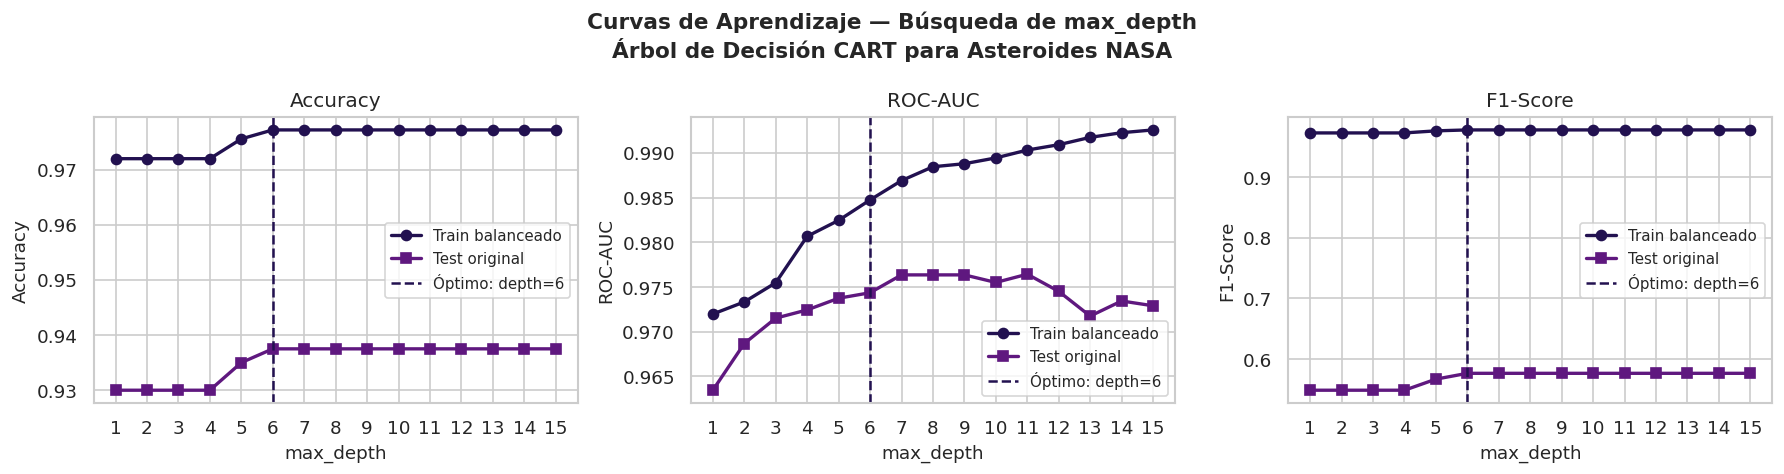

✅ Curvas de max_depth guardadas en data/graficas/max_depth_arbol_asteroides.png


In [11]:
# ── CELDA 7: Búsqueda de max_depth óptimo ────────────────────────────────────

# División base 80/20 para buscar la mejor profundidad
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Aplicar oversampling SOLO sobre entrenamiento
X_tr_bal, y_tr_bal = aplicar_oversampling(X_tr, y_tr, random_state=42)

# Rango de profundidades a evaluar
profundidades = range(1, 16)

acc_train, acc_test = [], []
auc_train, auc_test = [], []
f1_train, f1_test = [], []

for d in profundidades:
    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )

    # Entrenar con datos balanceados
    modelo.fit(X_tr_bal, y_tr_bal)

    # ── Métricas en entrenamiento balanceado ────────────────────────────────
    y_train_pred = modelo.predict(X_tr_bal)
    y_train_prob = modelo.predict_proba(X_tr_bal)[:, 1]

    acc_train.append(accuracy_score(y_tr_bal, y_train_pred))
    auc_train.append(roc_auc_score(y_tr_bal, y_train_prob))
    f1_train.append(f1_score(y_tr_bal, y_train_pred, zero_division=0))

    # ── Métricas en prueba original, NO balanceada ──────────────────────────
    y_test_pred = modelo.predict(X_te)
    y_test_prob = modelo.predict_proba(X_te)[:, 1]

    acc_test.append(accuracy_score(y_te, y_test_pred))
    auc_test.append(roc_auc_score(y_te, y_test_prob))
    f1_test.append(f1_score(y_te, y_test_pred, zero_division=0))


# Mejor max_depth según F1-Score en test
idx_mejor = int(np.argmax(f1_test))
mejor_depth = list(profundidades)[idx_mejor]

print("🏆 Mejor max_depth según F1-Score en prueba:")
print(f"   max_depth óptimo : {mejor_depth}")
print(f"   F1-Score test    : {f1_test[idx_mejor]:.4f}")
print(f"   Accuracy test    : {acc_test[idx_mejor]:.4f}")
print(f"   ROC-AUC test     : {auc_test[idx_mejor]:.4f}")

print("\n📌 Nota:")
print("   El modelo se entrena con datos balanceados, pero se evalúa con datos de prueba originales.")
print("   Esto permite medir su desempeño en una situación más realista.")
print("   El F1-Score se usa como criterio principal porque equilibra Precision y Recall.")


# ── Gráfico: curvas de entrenamiento vs prueba ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle(
    'Curvas de Aprendizaje — Búsqueda de max_depth\n'
    'Árbol de Decisión CART para Asteroides NASA',
    fontsize=13,
    fontweight='bold'
)

metricas_plot = [
    ('Accuracy', acc_train, acc_test),
    ('ROC-AUC', auc_train, auc_test),
    ('F1-Score', f1_train, f1_test),
]

for ax, (titulo, train_vals, test_vals) in zip(axes, metricas_plot):
    ax.plot(
        profundidades,
        train_vals,
        'o-',
        lw=2,
        label='Train balanceado'
    )

    ax.plot(
        profundidades,
        test_vals,
        's-',
        lw=2,
        label='Test original'
    )

    ax.axvline(
        x=mejor_depth,
        linestyle='--',
        lw=1.5,
        label=f'Óptimo: depth={mejor_depth}'
    )

    ax.set_xlabel('max_depth', fontsize=11)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xticks(list(profundidades))

plt.tight_layout()

# Crear carpeta si no existe
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig(
    '../data/graficas/max_depth_arbol_asteroides.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Curvas de max_depth guardadas en data/graficas/max_depth_arbol_asteroides.png")

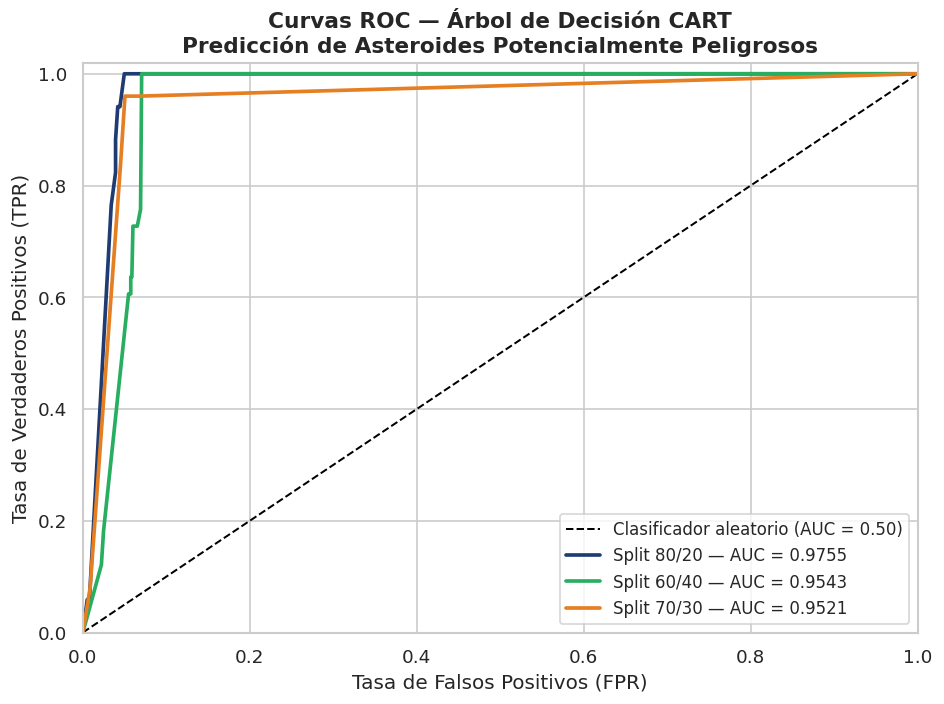

✅ Curvas ROC guardadas en data/graficas/roc_arbol_asteroides.png


In [12]:
# ── CELDA 8: Curvas ROC comparativas ─────────────────────────────────────────

COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))

# Línea base: clasificador aleatorio
ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    lw=1.2,
    label='Clasificador aleatorio (AUC = 0.50)'
)

# Curvas ROC para cada split
for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'],
        r['tpr'],
        color=color,
        lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)

ax.set_title(
    'Curvas ROC — Árbol de Decisión CART\n'
    'Predicción de Asteroides Potencialmente Peligrosos',
    fontsize=13,
    fontweight='bold'
)

ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()

# Crear carpeta si no existe
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig(
    '../data/graficas/roc_arbol_asteroides.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Curvas ROC guardadas en data/graficas/roc_arbol_asteroides.png")

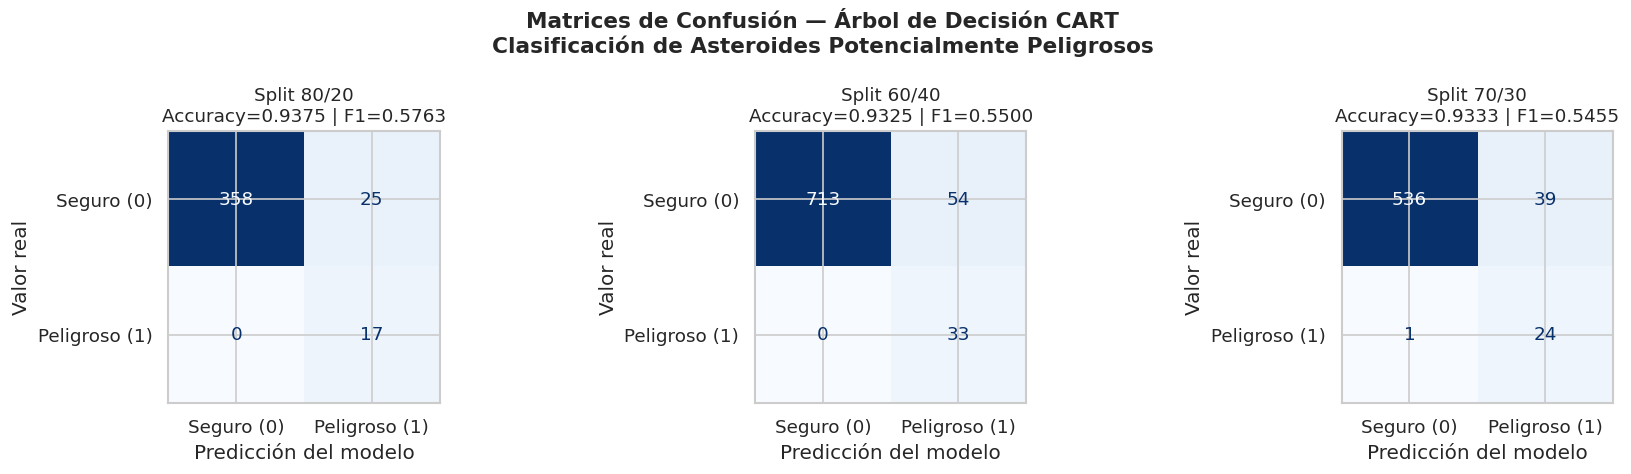

✅ Matrices de confusión guardadas en data/graficas/confusion_arbol_asteroides.png


In [13]:
# ── CELDA 9: Matrices de Confusión (3 splits) ────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle(
    'Matrices de Confusión — Árbol de Decisión CART\n'
    'Clasificación de Asteroides Potencialmente Peligrosos',
    fontsize=13,
    fontweight='bold'
)

for ax, r in zip(axes, resultados):
    cm = confusion_matrix(r['y_test'], r['y_pred'])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Seguro (0)', 'Peligroso (1)']
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap='Blues',
        values_format='d'
    )

    ax.set_title(
        f"{r['nombre']}\nAccuracy={r['accuracy']:.4f} | F1={r['f1']:.4f}",
        fontsize=11
    )

    ax.set_xlabel('Predicción del modelo')
    ax.set_ylabel('Valor real')

plt.tight_layout()

# Crear carpeta si no existe
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig(
    '../data/graficas/confusion_arbol_asteroides.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Matrices de confusión guardadas en data/graficas/confusion_arbol_asteroides.png")

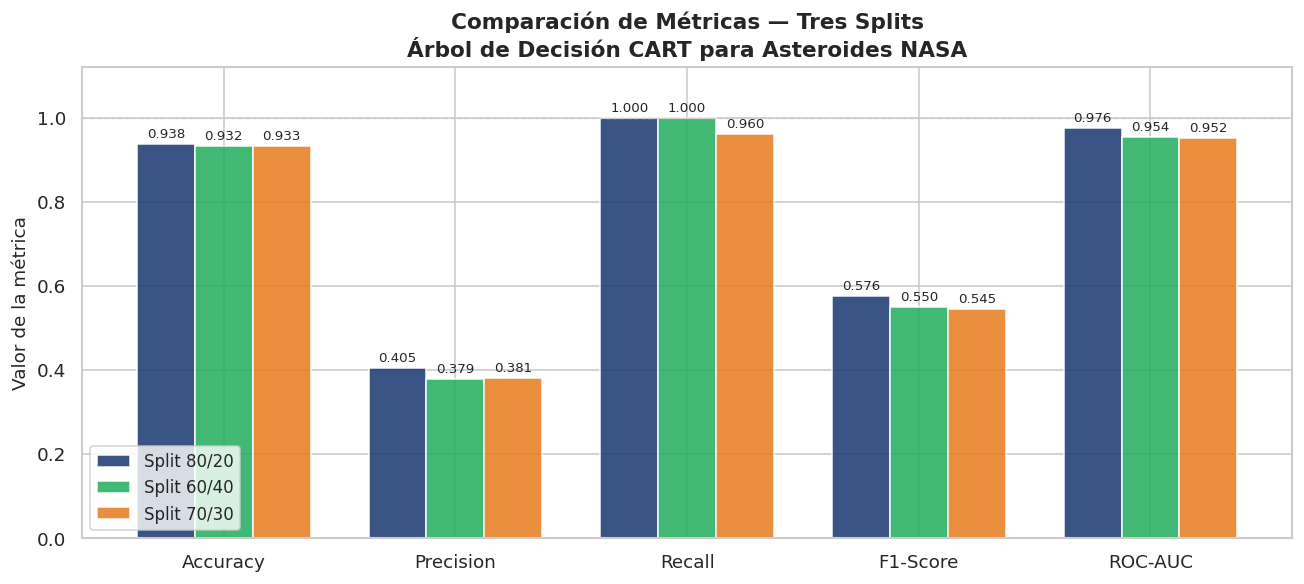

✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_arbol_asteroides.png


In [14]:
# ── CELDA 10: Gráfico comparativo de métricas ────────────────────────────────

metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=r['nombre'],
        color=color,
        alpha=0.88
    )

    ax.bar_label(
        bars,
        fmt='%.3f',
        padding=2,
        fontsize=8
    )

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la métrica', fontsize=11)

ax.set_title(
    'Comparación de Métricas — Tres Splits\n'
    'Árbol de Decisión CART para Asteroides NASA',
    fontsize=13,
    fontweight='bold'
)

ax.legend(fontsize=10)

ax.axhline(
    y=1.0,
    color='#ccc',
    linewidth=0.8,
    linestyle='--'
)

plt.tight_layout()

# Crear carpeta si no existe
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig(
    '../data/graficas/metricas_comparativas_arbol_asteroides.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_arbol_asteroides.png")

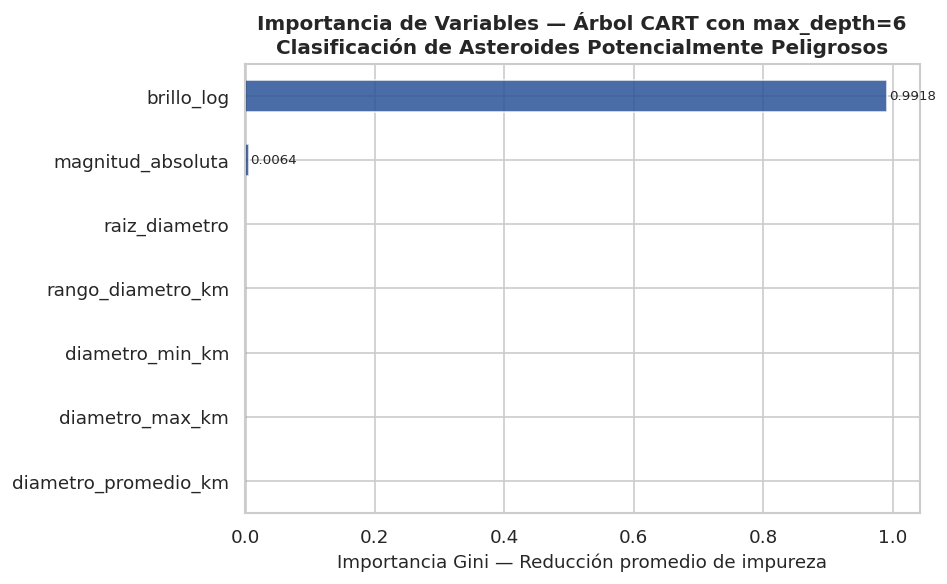

✅ Feature importance guardada en data/graficas/feature_importance_arbol_asteroides.png

📊 Suma de todas las importancias: 1.000000  (debe ser ≈ 1.0)

Top variables más importantes:
brillo_log              0.991841
magnitud_absoluta       0.006392
raiz_diametro           0.000839
rango_diametro_km       0.000422
diametro_min_km         0.000256
diametro_max_km         0.000249
diametro_promedio_km    0.000000


In [15]:
# ── CELDA 11: Importancia de variables (Feature Importance Gini) ─────────────

# Entrenamos un modelo de referencia usando el mejor max_depth encontrado
# Se usa el split 80/20 para mantener coherencia con la búsqueda de profundidad.

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Aplicar oversampling SOLO sobre entrenamiento
X_tr_bal, y_tr_bal = aplicar_oversampling(X_tr, y_tr, random_state=42)

# Modelo CART con la mejor profundidad encontrada
modelo_ref = DecisionTreeClassifier(
    criterion='gini',
    max_depth=mejor_depth,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

modelo_ref.fit(X_tr_bal, y_tr_bal)

# Importancias de las variables usadas en el modelo
importancias = pd.Series(
    modelo_ref.feature_importances_,
    index=X.columns
)

# Ordenar de menor a mayor para gráfico horizontal
importancias_ord = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

importancias_ord.plot(
    kind='barh',
    ax=ax,
    color='#2a5298',
    alpha=0.85
)

ax.set_xlabel(
    'Importancia Gini — Reducción promedio de impureza',
    fontsize=11
)

ax.set_title(
    f'Importancia de Variables — Árbol CART con max_depth={mejor_depth}\n'
    'Clasificación de Asteroides Potencialmente Peligrosos',
    fontsize=12,
    fontweight='bold'
)

ax.axvline(
    x=0,
    color='black',
    linewidth=0.8
)

# Anotar valores en cada barra
for patch in ax.patches:
    width = patch.get_width()
    if width > 0.001:
        ax.text(
            width + 0.002,
            patch.get_y() + patch.get_height() / 2,
            f'{width:.4f}',
            va='center',
            fontsize=8
        )

plt.tight_layout()

# Crear carpeta si no existe
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig(
    '../data/graficas/feature_importance_arbol_asteroides.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Feature importance guardada en data/graficas/feature_importance_arbol_asteroides.png")

print(f"\n📊 Suma de todas las importancias: {importancias.sum():.6f}  (debe ser ≈ 1.0)")

print("\nTop variables más importantes:")
print(importancias.sort_values(ascending=False).to_string())